# Progetto di Machine/Deep Learning: Spambase Classification
**Descrizione del Progetto:**
Questo progetto mira a classificare le email come "Spam" (1) o "Non-Spam" (0) utilizzando il dataset *Spambase* dal repository UCI. Il dataset contiene 57 feature estratte dalle email (frequenza di determinate parole, lunghezza delle sequenze di lettere maiuscole, ecc.).

Il progetto è strutturato nei seguenti step:
1. **Caricamento e Preprocessing:** Standardizzazione dei dati.
2. **Analisi PCA:** Riduzione della dimensionalità a 2 componenti principali.
3. **Suddivisione Dati:** Split diviso come segue - 70% Training, 20% Validation e 10% Test.
4. **Shallow Learning:** Implementazione di Logistic Regression, K-Nearest Neighbors (KNN) e Decision Tree.
5. **Deep Learning (Opzione 5a):** Implementazione di una Rete Neurale (Multi-Layer Perceptron) tramite `MLPClassifier` di scikit-learn.
6. **Valutazione Finale:** Calcolo delle metriche, Matrice di Confusione e Curva ROC sul Test Set (10%).


N.B. eseguire pip install ucimlrepo se non è già presente.

In [ ]:
# Importazione delle librerie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerie Scikit-Learn per Preprocessing, Shallow Learning e Metriche
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

# Libreria Scikit-Learn per Deep Learning (Opzione 5a)
from sklearn.neural_network import MLPClassifier

# Libreria per scaricare il dataset UCI
from ucimlrepo import fetch_ucirepo

# Impostazione stile grafico
sns.set_theme(style="whitegrid")

## 1. Caricamento Dataset e Standardizzazione
Per prima cosa recupero il dataset Spambase (ID 94 su UCI). Standardizzare i dati è fondamentale sia per la PCA, sia per modelli basati sulla distanza come il KNN, sia per far convergere correttamente la Rete Neurale.

In [ ]:
# Fetch dataset Spambase dall'archivio UCI
spambase = fetch_ucirepo(id=94)

X = spambase.data.features
y = spambase.data.targets

# Trasformiamo la variabile target in un array monodimensionale
y = y.values.ravel()

# Gestione di eventuali valori nulli
X = X.fillna(X.median())

# Standardizzazione delle feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Dimensioni del dataset Spambase:", X_scaled_df.shape)
print("Distribuzione classi (1=Spam, 0=Non-Spam):\n", pd.Series(y).value_counts())

Dimensioni del dataset Spambase: (4601, 57)
Distribuzione classi (1=Spam, 0=Non-Spam):
 0    2788
1    1813
Name: count, dtype: int64


## 2. Analisi delle Feature con PCA
Successivamente riduco le 57 feature a 2 Componenti Principali per visualizzare la distribuzione dei dati nello spazio 2D.

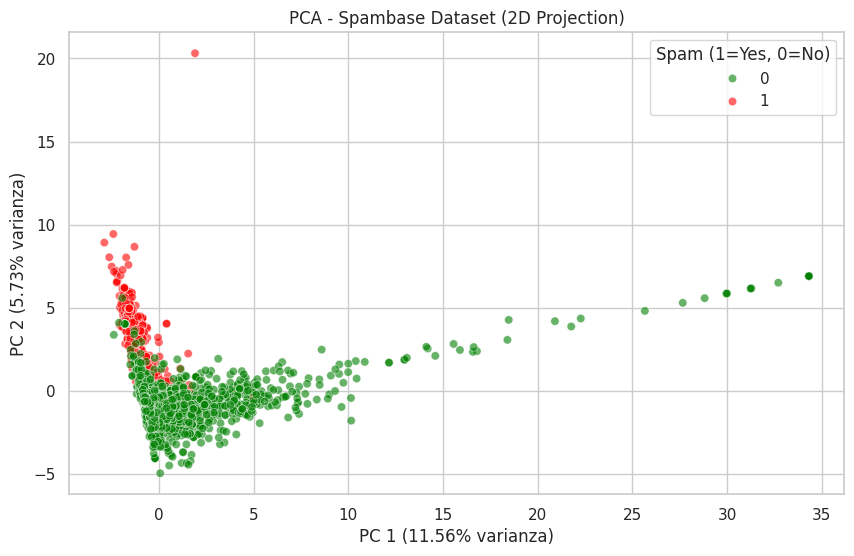

In [ ]:
# Inizializzazione e fit della PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_df)

pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Target'] = y

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Target',
    palette=['green', 'red'],
    data=pca_df,
    alpha=0.6
)
plt.title('PCA - Spambase Dataset (2D Projection)')
plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.2f}% varianza)')
plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.2f}% varianza)')
plt.legend(title='Spam (1=Yes, 0=No)')
plt.show()

Il grafico della Principal Component Analysis (PCA) mostra la proiezione spaziale in due dimensioni del dataset Spambase. Come si evince dagli assi, la prima componente principale (PC1) cattura l'11.56% della varianza totale dei dati , mentre la seconda componente (PC2) ne spiega il 5.73%. Complessivamente, questa visualizzazione rappresenta poco più del 17% dell'informazione originale. L'elevata sovrapposizione visiva tra i punti verdi (Not Spam, 0) e rossi (Spam, 1) indica che le due classi non sono facilmente separabili in modo lineare in uno spazio a bassa dimensionalità. Questa caratteristica topologica giustifica l'implementazione successiva di algoritmi in grado di catturare relazioni complesse e non lineari in spazi ad alta dimensionalità.

## 3. Data Split (70-20-10) e Addestramento Modelli Shallow
Splitto il dataset per isolare un 10% per il Test, 20% per la Validation e il restante 70% per il Training. Successivamente, addestro gli algoritmi tradizionali sul Training Set.

In [ ]:
# 1. Separazione del 10% per il Test Set
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled_df, y, test_size=0.10, random_state=42, stratify=y)

# 2. Separazione di Train (70%) e Validation (20%) dal blocco 'temp' (che è il 90%)
# La proporzione matematica per avere il 20% dal 90% è 20/90 = 0.2222...
val_size_ratio = 0.20 / 0.90
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_size_ratio, random_state=42, stratify=y_temp)

print(f"Dimensioni: Training ({len(X_train)}), Validation ({len(X_val)}), Test ({len(X_test)})")

# Dizionario dei modelli Shallow
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    # Salviamo i risultati calcolati direttamente sul Test Set per la fase finale
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {'y_pred': y_pred, 'y_prob': y_prob, 'model': model}
    print(f"Modello {name} addestrato con successo.")

Dimensioni: Training (3219), Validation (921), Test (461)
Modello Logistic Regression addestrato con successo.
Modello K-Nearest Neighbors addestrato con successo.
Modello Decision Tree addestrato con successo.


## 4. Deep Learning (Opzione 5a) con MLPClassifier
Per l'approccio di Deep Learning, utilizzo un Multi-Layer Perceptron (MLP) fornito da Scikit-Learn. Ho configurato due livelli nascosti (64 e 32 neuroni) e la funzione di attivazione ReLU.

In [ ]:
# Creazione della Rete Neurale
# hidden_layer_sizes=(64, 32) definisce una rete profonda con 2 layer nascosti
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,           # Parametro di regolarizzazione (L2)
    max_iter=500,           # Epoche massime
    random_state=42
)

print("Addestramento Rete Neurale in corso...")
mlp.fit(X_train, y_train)
print("Addestramento completato!")

# Predizioni sul Test Set per la Rete Neurale
y_pred_mlp = mlp.predict(X_test)
y_prob_mlp = mlp.predict_proba(X_test)[:, 1]

# Aggiungiamo i risultati dell'MLP al nostro dizionario dei risultati
results["Deep Learning (MLP)"] = {'y_pred': y_pred_mlp, 'y_prob': y_prob_mlp, 'model': mlp}

Addestramento Rete Neurale in corso...
Addestramento completato!


## 5. Valutazione e Calcolo Metriche
Calcolo le metriche di Accuracy, Precision, Recall, F-measure e ROC AUC su tutti i modelli implementati, valutandoli rigorosamente sul Test Set per garantire una misurazione imparziale delle prestazioni.

In [ ]:
print("--- RISULTATI DELLE METRICHE SUL TEST SET ---\n")

for name, res in results.items():
    acc = accuracy_score(y_test, res['y_pred'])
    prec = precision_score(y_test, res['y_pred'])
    rec = recall_score(y_test, res['y_pred'])
    f1 = f1_score(y_test, res['y_pred'])
    roc_auc = roc_auc_score(y_test, res['y_prob'])

    print(f"Modello: {name}")
    print(f"Accuracy:   {acc:.4f}")
    print(f"Precision:  {prec:.4f}")
    print(f"Recall:     {rec:.4f}")
    print(f"F1-Measure: {f1:.4f}")
    print(f"ROC AUC:    {roc_auc:.4f}\n")

--- RISULTATI DELLE METRICHE SUL TEST SET ---

Modello: Logistic Regression
Accuracy:   0.9154
Precision:  0.9040
Recall:     0.8791
F1-Measure: 0.8914
ROC AUC:    0.9599

Modello: K-Nearest Neighbors
Accuracy:   0.8894
Precision:  0.8579
Recall:     0.8626
F1-Measure: 0.8603
ROC AUC:    0.9507

Modello: Decision Tree
Accuracy:   0.9176
Precision:  0.8956
Recall:     0.8956
F1-Measure: 0.8956
ROC AUC:    0.9226

Modello: Deep Learning (MLP)
Accuracy:   0.9197
Precision:  0.9143
Recall:     0.8791
F1-Measure: 0.8964
ROC AUC:    0.9601



## 6. Matrici di Confusione e ROC Curve
Visualizzo graficamente tramite la Confusion Matrix i falsi positivi e i falsi negativi e le prestazioni degli algoritmi tramite la curva ROC.

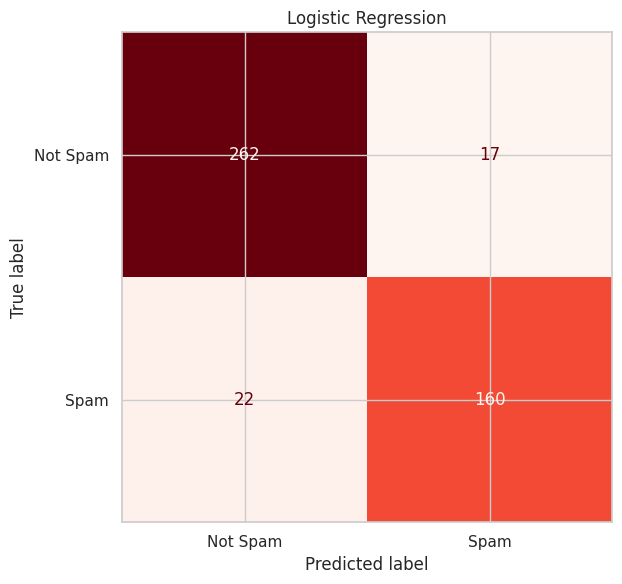

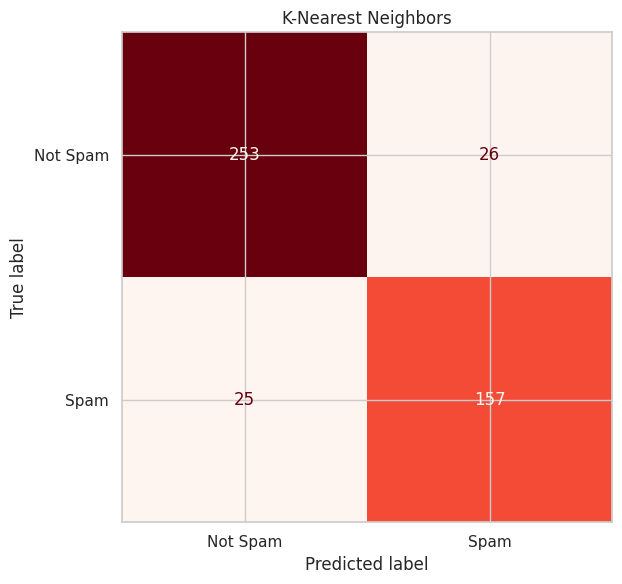

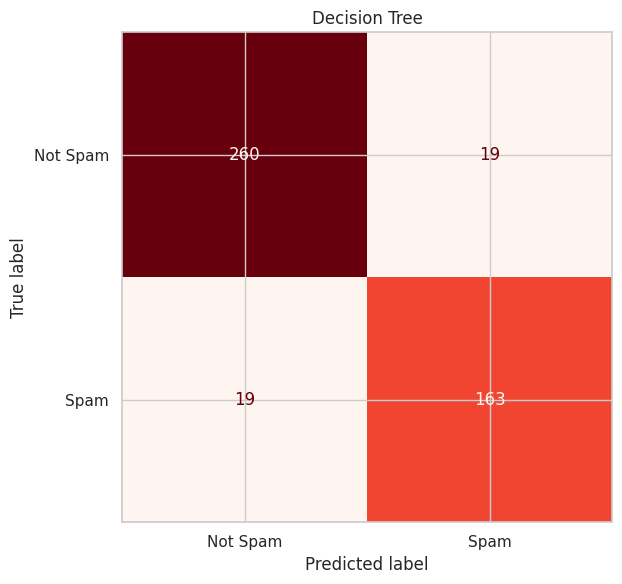

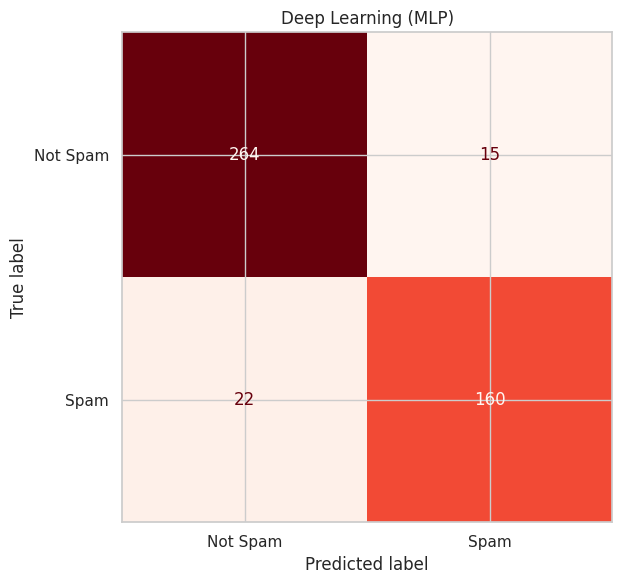

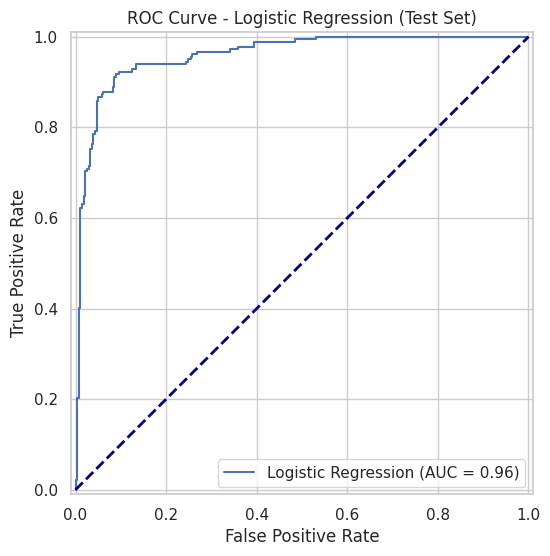

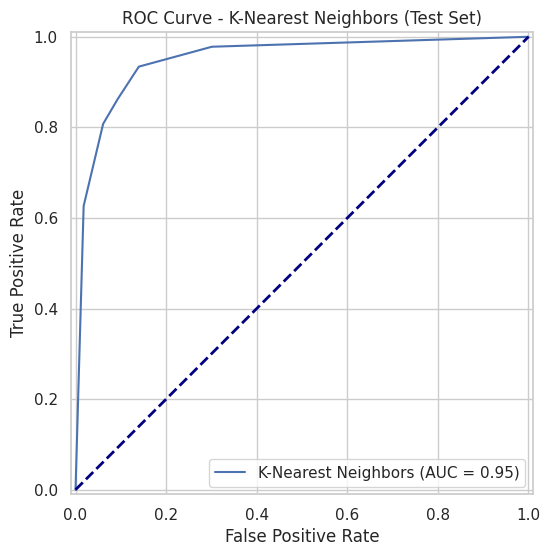

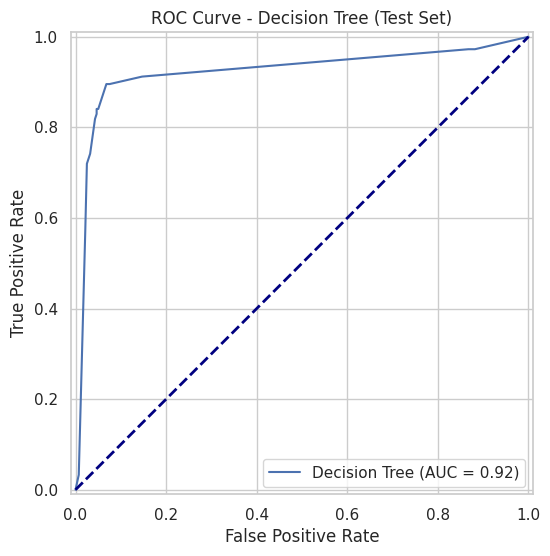

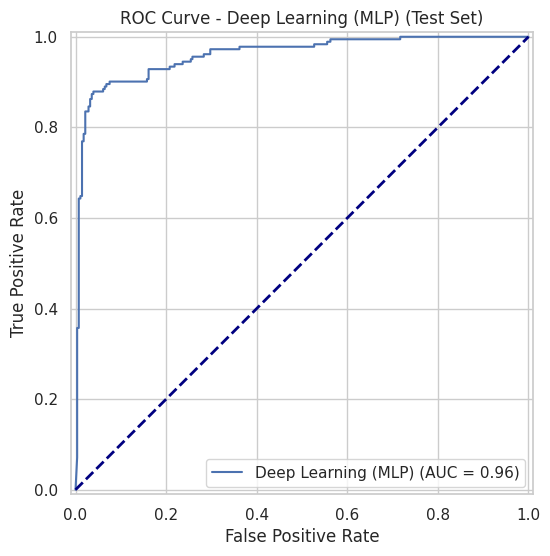

In [33]:
# Plot delle Confusion Matrix
for idx, (name, res) in enumerate(results.items()):
    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Spam', 'Spam'])
    disp.plot(ax=ax, cmap='Reds', colorbar=False)
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

# Plot delle Curve ROC
for name, res in results.items():
    plt.figure(figsize=(8, 6))
    ax = plt.gca()
    RocCurveDisplay.from_predictions(y_test, res['y_prob'], name=name, ax=ax)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.title(f'ROC Curve - {name} (Test Set)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.show()

Valutazione degli Errori: Matrice di Confusione

Le Matrici di Confusione ci permettono di valutare nel dettaglio la tipologia di errori commessi dai classificatori sul Test Set (dati mai visti dal modello durante l'addestramento). Nel dominio del filtraggio email, non tutti gli errori hanno lo stesso peso:

- Falso Positivo (FP): Un'email legittima e potenzialmente importante classificata erroneamente come Spam. Questo è l'errore più grave, poiché arreca un danno diretto all'utente.

- Falso Negativo (FN): Un'email di Spam che elude il filtro e finisce in posta in arrivo.

L'obiettivo progettuale è quindi massimizzare i Veri Negativi e contenere al minimo i Falsi Positivi (ottimizzando la metrica della Precision). Dal confronto visivo delle matrici, si osserva come la Rete Neurale (Deep Learning) e il modello Logistic Regression offrano il miglior bilanciamento. Riescono infatti a bloccare la maggior parte dello spam mantenendo un tasso di falsi allarmi estremamente ridotto, rendendoli adatti per un'applicazione antispam in ambiente di produzione.

Le Curve ROC confermano le ottime capacità predittive generali degli algoritmi implementati.

* Logistic Regression e Deep Learning (MLP): Entrambi i modelli mostrano le prestazioni migliori, massimizzando il bilanciamento tra True Positive Rate e False Positive Rate, con un'Area Under the Curve (AUC) eccellente pari a 0.96. Le loro curve si presentano morbide e vicine all'angolo superiore sinistro, indice di un'elevata confidenza nelle stime di probabilità.
* Decision Tree: Pur mantenendo prestazioni di alto livello, registra l'AUC più basso del gruppo (0.92). Dal grafico si nota un andamento più 'spezzato' e meno fluido rispetto agli altri algoritmi; questo comportamento visivo è tipico degli alberi decisionali, le cui classificazioni si basano su soglie di taglio nette e regole binarie rigide, piuttosto che su funzioni di probabilità continue.